In [48]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


https://medium.com/@noorfatimaafzalbutt/the-perceptron-trick-a-simple-guide-to-training-a-perceptron-b298f7ca9509# <br>
### Good Read for using Perceptron for Logistic Regression

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score

In [89]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

In [90]:
train.shape

(594194, 21)

## Basic EDA

In [52]:
train['Churn'].value_counts(normalize=True) * 100


Churn
No     77.479241
Yes    22.520759
Name: proportion, dtype: float64

In [53]:
info = pd.DataFrame({
    "dtype":   train.dtypes,
    "missing": train.isnull().sum(),
    "unique":  train.nunique(),
})
print(info.to_string())

                    dtype  missing  unique
id                  int64        0  594194
gender             object        0       2
SeniorCitizen       int64        0       2
Partner            object        0       2
Dependents         object        0       2
tenure              int64        0      72
PhoneService       object        0       2
MultipleLines      object        0       3
InternetService    object        0       3
OnlineSecurity     object        0       3
OnlineBackup       object        0       3
DeviceProtection   object        0       3
TechSupport        object        0       3
StreamingTV        object        0       3
StreamingMovies    object        0       3
Contract           object        0       3
PaperlessBilling   object        0       2
PaymentMethod      object        0       4
MonthlyCharges    float64        0    1921
TotalCharges      float64        0   31910
Churn              object        0       2


In [54]:
object_cols = list(train.select_dtypes(include='object').columns)
for i in object_cols:
    print(f'Unique values for {i} are:\n{train[i].unique()}\n')

Unique values for gender are:
['Male' 'Female']

Unique values for Partner are:
['Yes' 'No']

Unique values for Dependents are:
['Yes' 'No']

Unique values for PhoneService are:
['Yes' 'No']

Unique values for MultipleLines are:
['No' 'Yes' 'No phone service']

Unique values for InternetService are:
['DSL' 'Fiber optic' 'No']

Unique values for OnlineSecurity are:
['Yes' 'No' 'No internet service']

Unique values for OnlineBackup are:
['No' 'Yes' 'No internet service']

Unique values for DeviceProtection are:
['Yes' 'No' 'No internet service']

Unique values for TechSupport are:
['Yes' 'No' 'No internet service']

Unique values for StreamingTV are:
['No' 'Yes' 'No internet service']

Unique values for StreamingMovies are:
['No' 'Yes' 'No internet service']

Unique values for Contract are:
['One year' 'Two year' 'Month-to-month']

Unique values for PaperlessBilling are:
['Yes' 'No']

Unique values for PaymentMethod are:
['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank

In [25]:
train.corr(numeric_only=True)

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
id,1.000000,0.002035,0.019322,0.005729,0.014331
SeniorCitizen,0.002035,1.000000,-0.084291,0.229079,0.042786
tenure,0.019322,-0.084291,1.000000,0.124043,0.769703
MonthlyCharges,0.005729,0.229079,0.124043,1.000000,0.634237
TotalCharges,0.014331,0.042786,0.769703,0.634237,1.000000


## EDA

In [56]:
sns.set_palette('Paired')
sns.set(style='whitegrid')

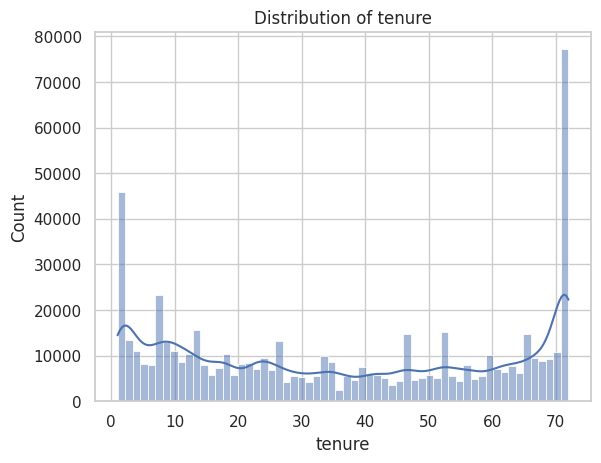

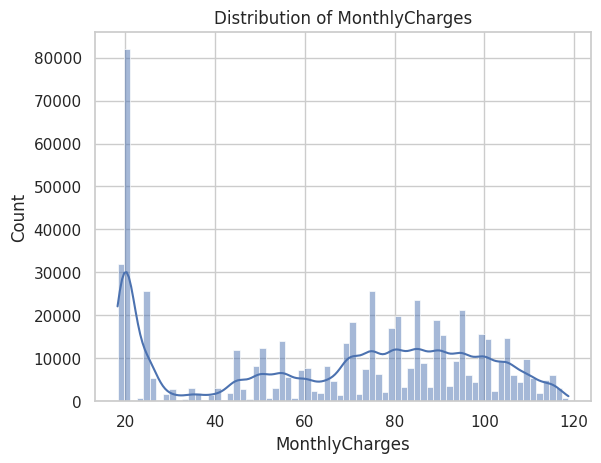

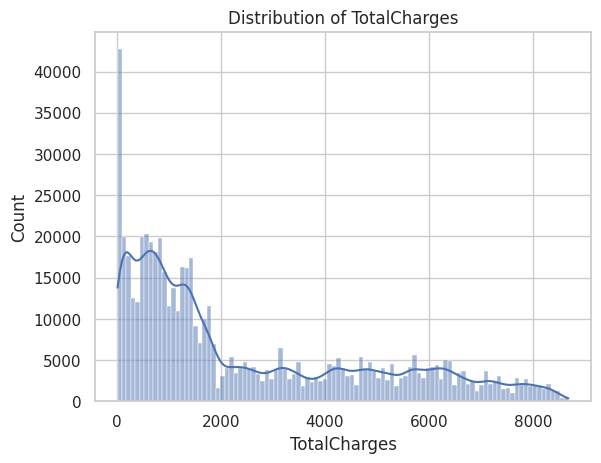

In [61]:
# Numerical distributions
num_cols = list(train.select_dtypes(include=['int64', 'float64']).columns)
num_cols.remove('id')
num_cols.remove('SeniorCitizen')
for col in num_cols:
    plt.figure()
    sns.histplot(train[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

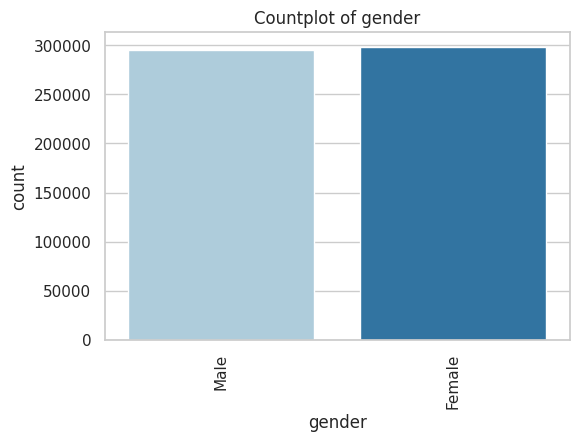

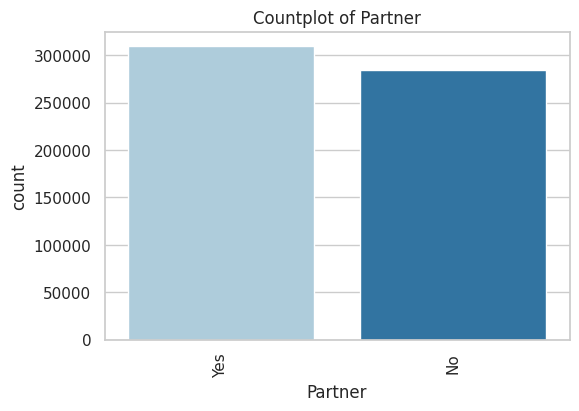

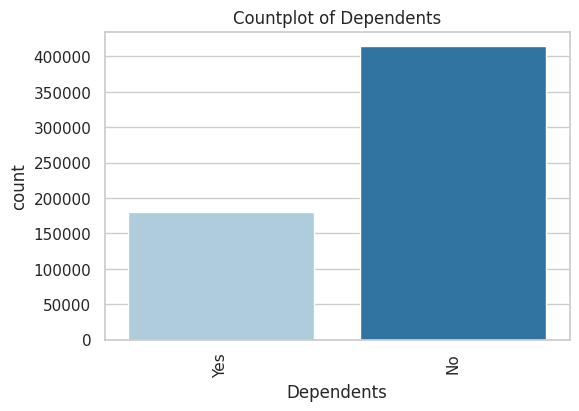

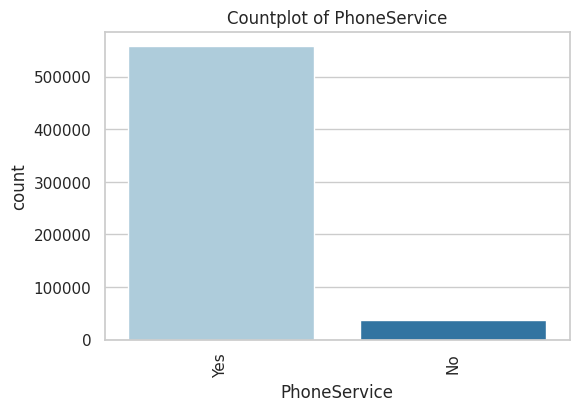

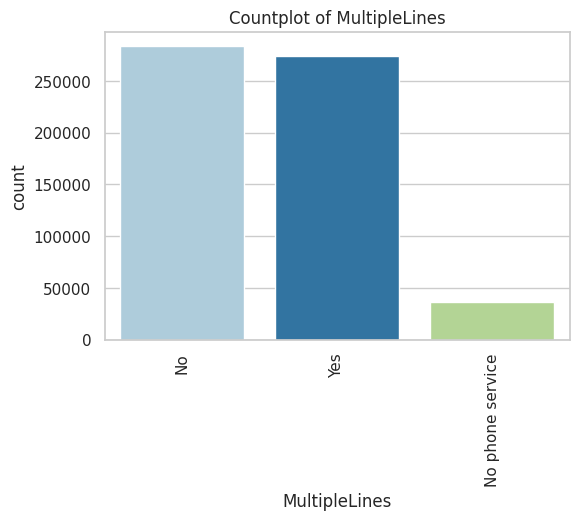

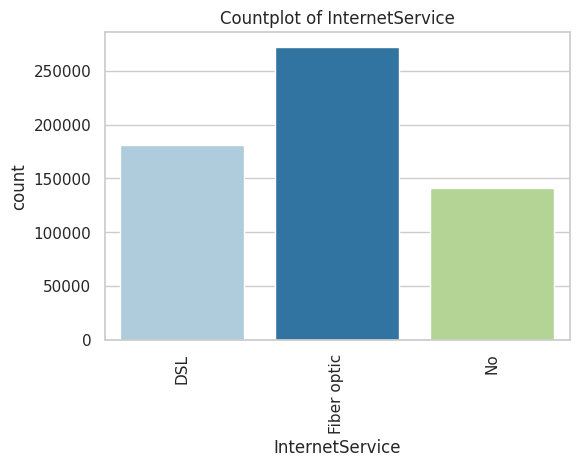

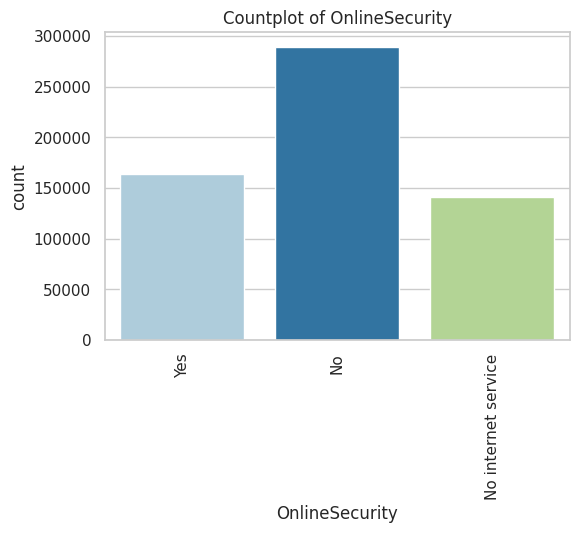

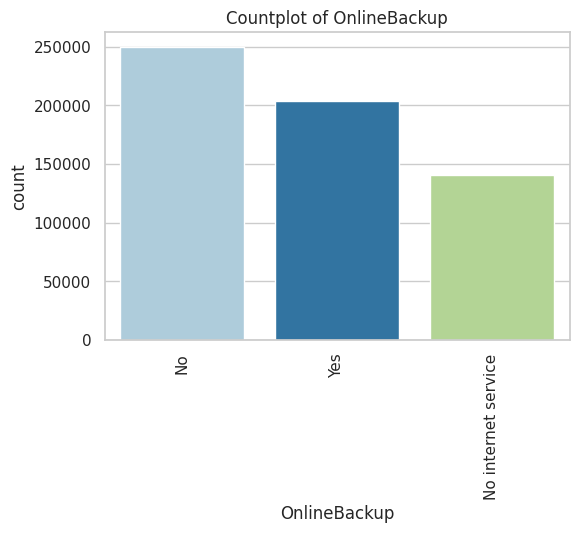

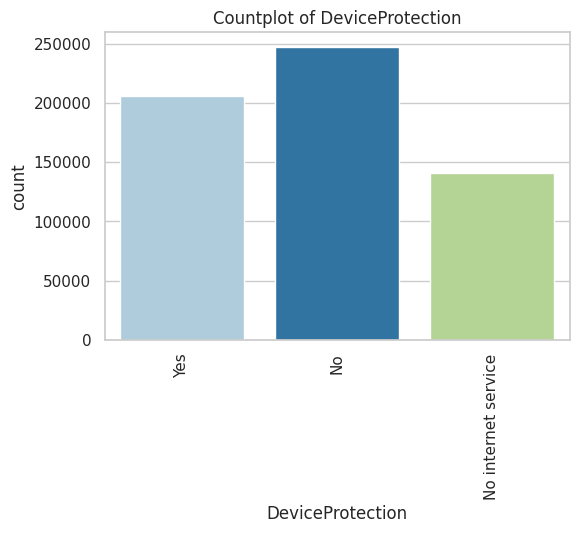

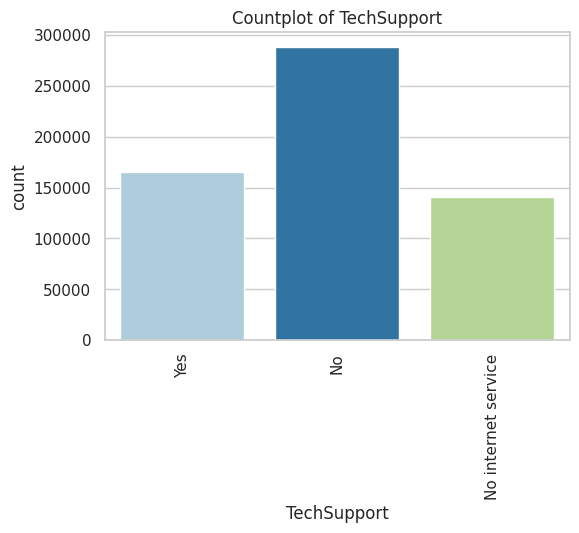

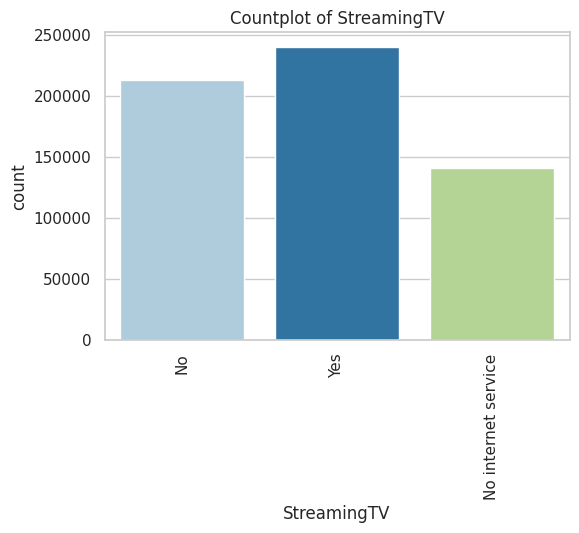

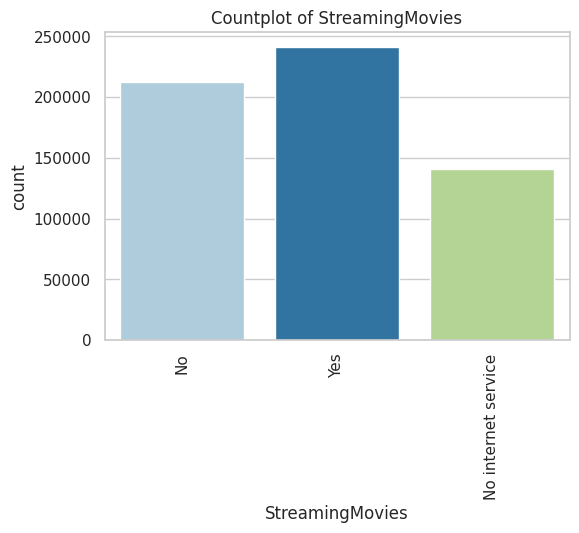

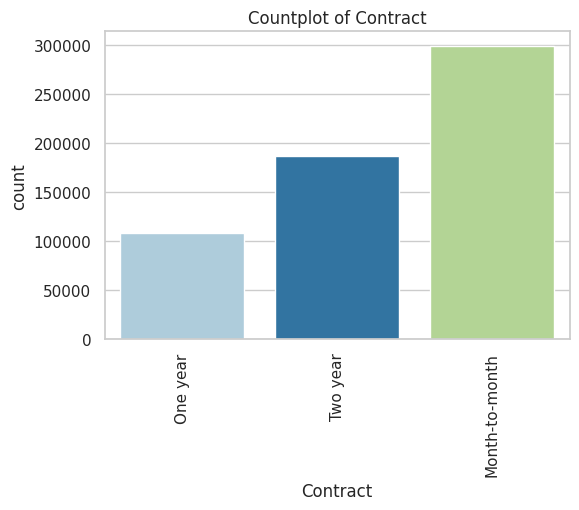

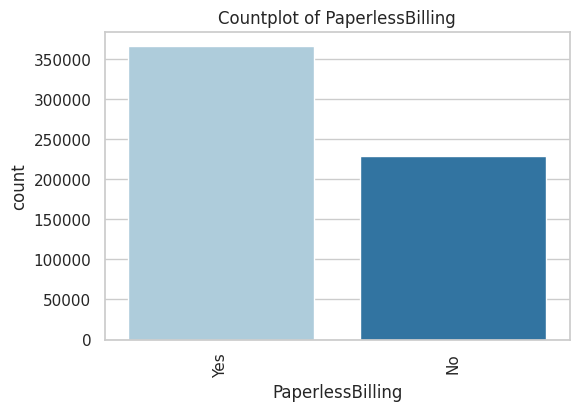

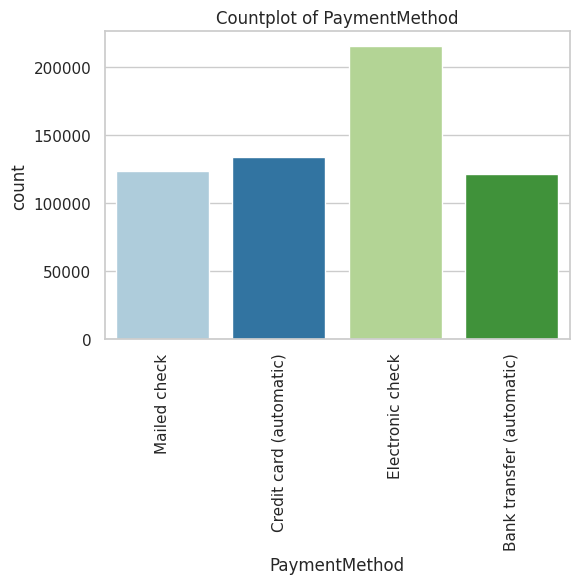

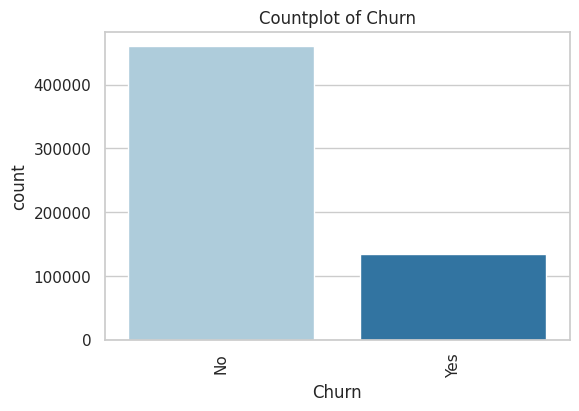

In [62]:
# Countplot of object columns
for col in object_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=train, x=col, hue=col, palette='Paired')
    plt.xticks(rotation=90)
    plt.title(f'Countplot of {col}')
    plt.show()

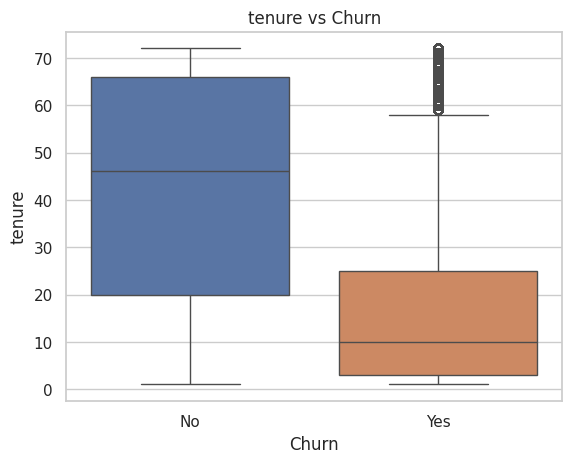

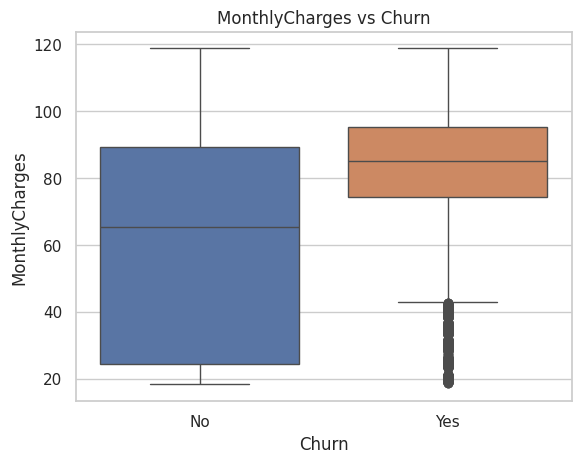

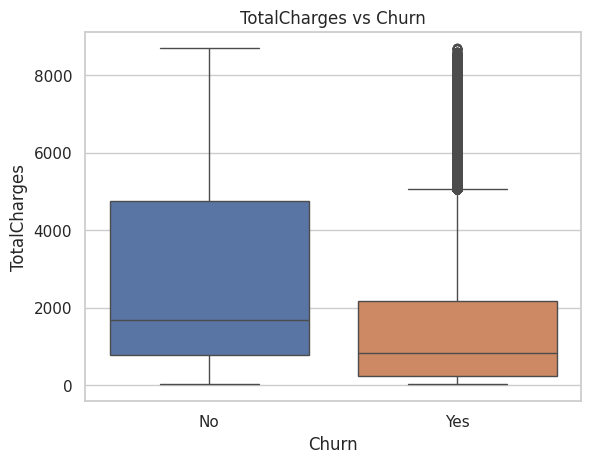

In [63]:
# Numerical columns vs churn
for col in num_cols:
    plt.figure()
    sns.boxplot(x='Churn', y=col, data=train, hue='Churn', legend=False)
    plt.title(f'{col} vs Churn')
    plt.show()

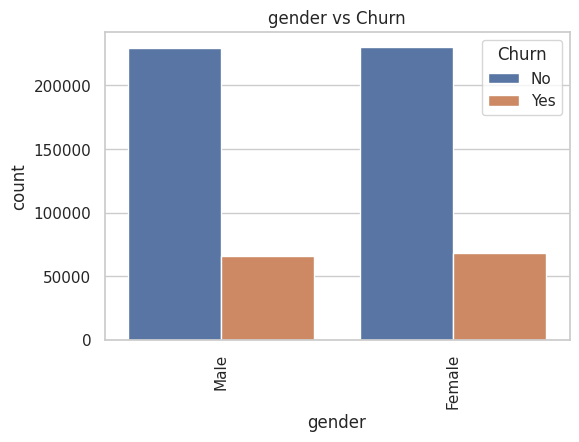

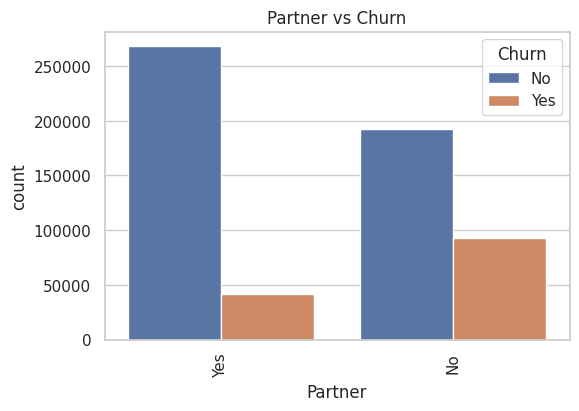

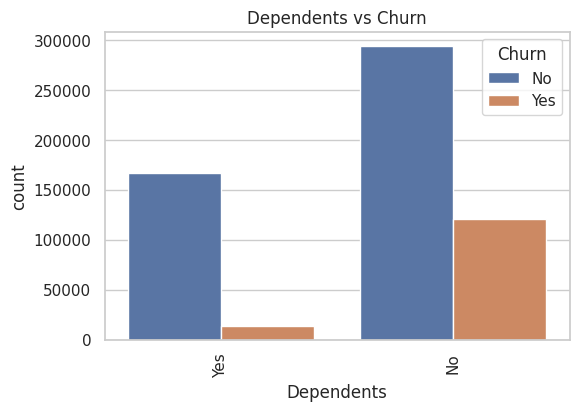

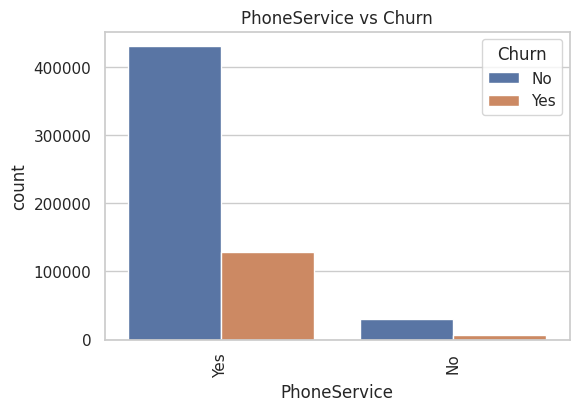

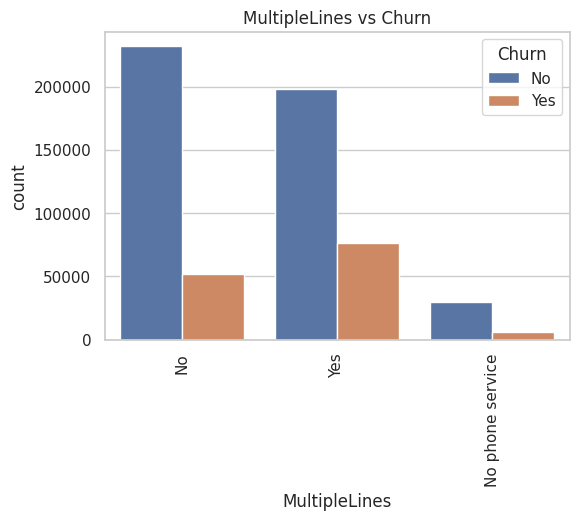

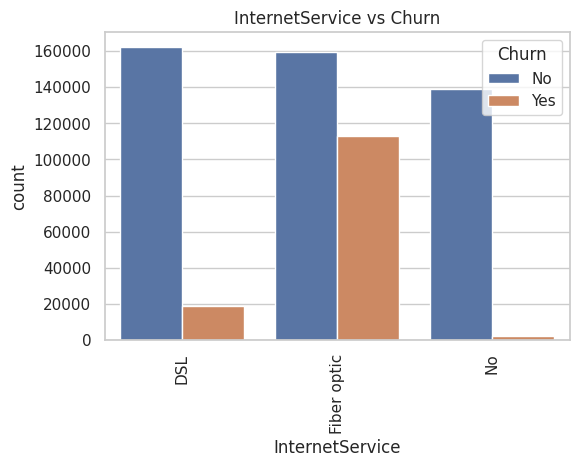

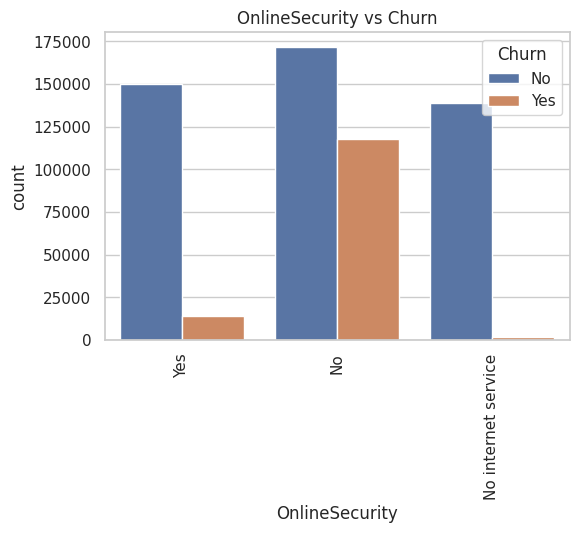

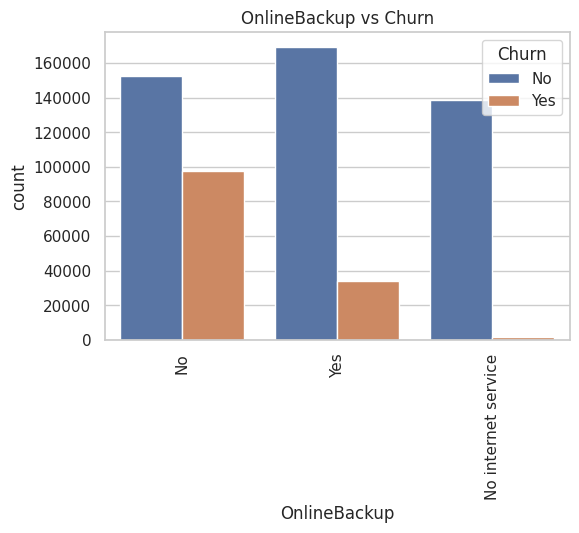

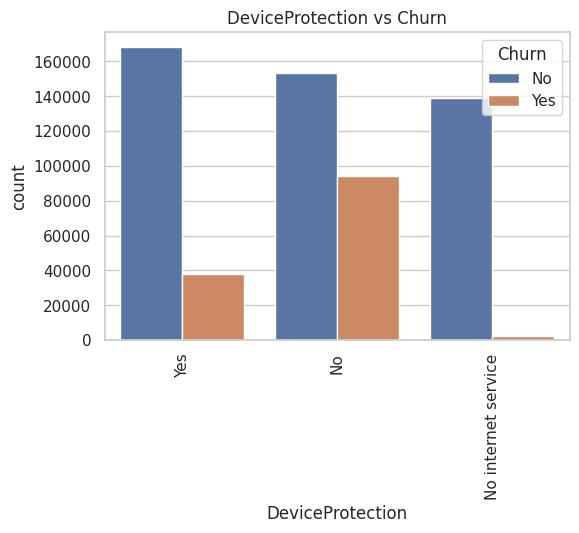

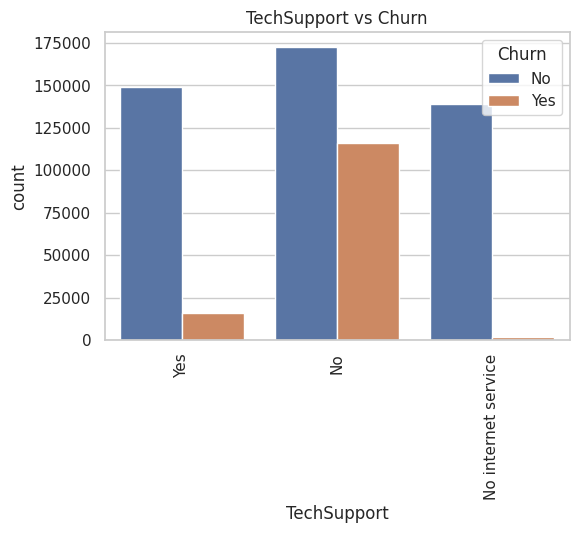

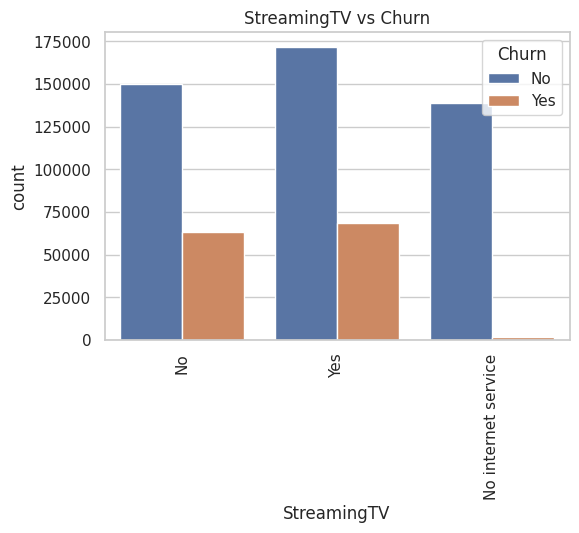

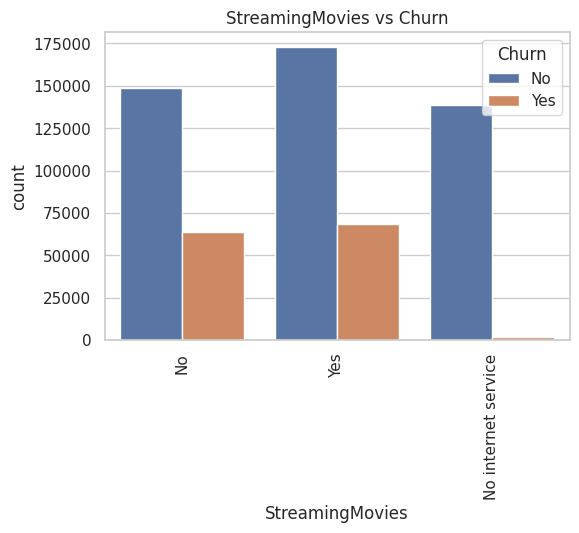

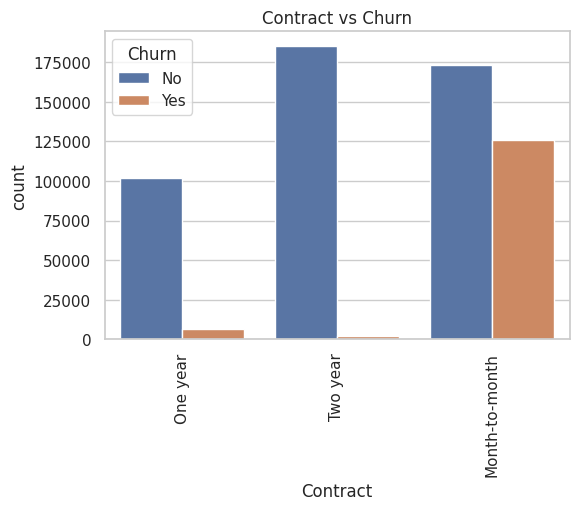

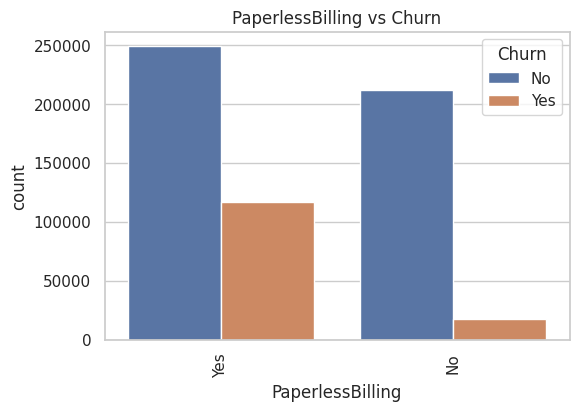

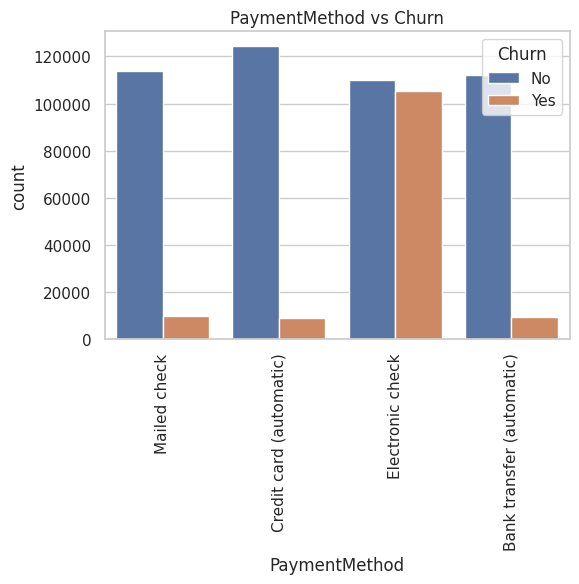

In [64]:
# Object column vs churn
for col in object_cols:
    if col != 'Churn':
        plt.figure(figsize=(6,4))
        sns.countplot(data=train, x=col, hue='Churn')
        plt.xticks(rotation=90)
        plt.title(f'{col} vs Churn')
        plt.show()

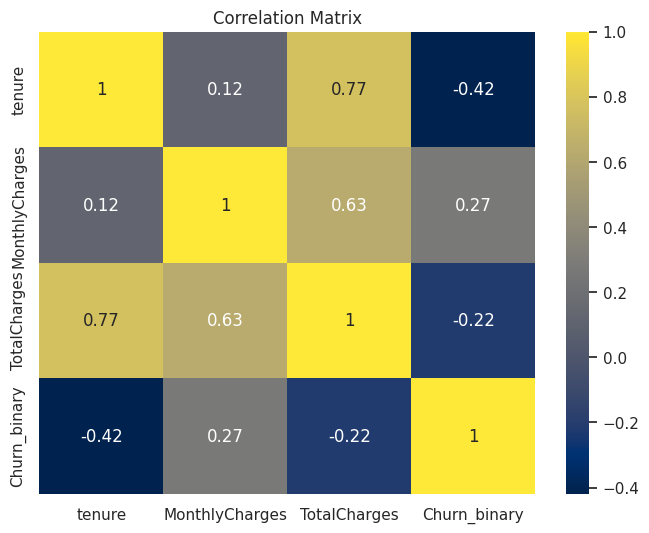

In [65]:
# Correlation matrix using Pearson's correlation coefficient
train['Churn_binary'] = train['Churn'].map({'Yes':1, 'No':0})
plt.figure(figsize=(8,6))
sns.heatmap(train[num_cols + ['Churn_binary']].corr(), annot=True, cmap='cividis')
plt.title('Correlation Matrix')
plt.show()

In [67]:
# High Correlation between tenure and TotalCharges

## Cleaning the Dataset

In [26]:
def clean_data(df):
    df = df.copy()
    
    # Fix internet structural issue
    internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']
    for col in internet_cols:
        if col in df.columns:
            df[col] = df[col].replace("No internet service", "No")
    
    return df

train = clean_data(train)
test = clean_data(test)

In [27]:
object_cols = list(train.select_dtypes(include='object').columns)
for i in object_cols:
    print(f'Unique values for {i} are:\n{train[i].unique()}\n')

Unique values for gender are:
['Male' 'Female']

Unique values for Partner are:
['Yes' 'No']

Unique values for Dependents are:
['Yes' 'No']

Unique values for PhoneService are:
['Yes' 'No']

Unique values for MultipleLines are:
['No' 'Yes' 'No phone service']

Unique values for InternetService are:
['DSL' 'Fiber optic' 'No']

Unique values for OnlineSecurity are:
['Yes' 'No']

Unique values for OnlineBackup are:
['No' 'Yes']

Unique values for DeviceProtection are:
['Yes' 'No']

Unique values for TechSupport are:
['Yes' 'No']

Unique values for StreamingTV are:
['No' 'Yes']

Unique values for StreamingMovies are:
['No' 'Yes']

Unique values for Contract are:
['One year' 'Two year' 'Month-to-month']

Unique values for PaperlessBilling are:
['Yes' 'No']

Unique values for PaymentMethod are:
['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']

Unique values for Churn are:
['No' 'Yes']



In [28]:
#Charge_Difference = TotalCharges - (MonthlyCharges * tenure)

train['Charge_Difference'] = train['TotalCharges'] - (train['MonthlyCharges'] * train['tenure'])
test['Charge_Difference'] = test['TotalCharges'] - (test['MonthlyCharges'] * test['tenure'])


In [70]:
# Remove collinearity columns
for col in ["TotalCharges", "MultipleLines_No phone service"]:
    if col in train.columns:
        train = train.drop(columns=[col])
        test = test.drop(columns=[col])

## Beginning setting up the Logistic Regression

In [74]:
X_train_index = train.iloc[:,0]
y = train['Churn']
X = train.drop(['Churn','Churn_binary'],axis=1)

X_test_index = test.iloc[:,0]
X_test = test[X.columns]

In [75]:
X_train_index.head()

0    0
1    1
2    2
3    3
4    4
Name: id, dtype: int64

In [76]:
y.head()

0     No
1     No
2     No
3    Yes
4    Yes
Name: Churn, dtype: object

In [77]:
X.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45


In [78]:
X_test_index.head()

0    594194
1    594195
2    594196
3    594197
4    594198
Name: id, dtype: int64

In [79]:
X_test.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35


## Logistic Regression

In [80]:
le = LabelEncoder()

In [81]:
def encoding(df):
    string_cols = df.select_dtypes(include=['object', 'category']).columns
    le = LabelEncoder()
    
    for col in string_cols:
        df[col] = le.fit_transform(df[col].astype(str))
    return df

In [82]:
X = encoding(X)
X_test = encoding(X_test)

In [83]:
scaler = StandardScaler()

X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

In [84]:
model = LogisticRegression(max_iter=2000)
model.fit(X, y)

LogisticRegression(max_iter=2000)

In [85]:
y_pred = model.predict_proba(X_test)[:, 1]
y_pred

array([2.73534090e-02, 5.11531291e-04, 1.14787455e-01, ...,
       2.87053248e-01, 7.36398289e-03, 5.27724313e-01])

## Prepping the Submission File

In [86]:
submission = X_test_index.copy()
submission = pd.DataFrame({'id': submission})
submission['Churn'] = y_pred

In [87]:
submission.head()

,id,Churn
0,594194,0.027353
1,594195,0.000512
2,594196,0.114787
3,594197,0.002951
4,594198,0.420903


In [88]:
submission.to_csv('submission.csv', index=False)


## End